In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster
from matplotlib.patches import Rectangle

In [2]:
df = pd.read_csv("../data/processed_dataset_rerun.csv")

In [3]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [4]:
X["log(Ipc)"] = np.log10(X["Ipc"])

C:\Users\thibo\AppData\Local\Temp\ipykernel_27248\1707251930.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X["log(Ipc)"] = np.log10(X["Ipc"])


In [22]:
top10_feats = [
    # 'molecular_polarizability_anisotropy',
    # 'MolLogP',
    # 'PEOE_VSA6',
    # 'ir_mode_count_1500_2750',
    # 'molecular_polarizability_mean',
    # 'BertzCT',
    # 'radius_of_gyration',
    # 'MolWt',
    # 'log(Ipc)',
    # 'solvation_energy_water',

    'TPSA',
    'SMR_VSA1',
    'SlogP_VSA2',
    'avg_atomic_quadrupole_principal_invariant_2',
    'std_atomic_charge_quadrupole_interaction',
    'avg_atomic_dipole_norm',
    'std_nuclear_repulsion',
    'avg_nuclear_repulsion',
    'avg_bond_length',
    'avg_atomic_polarizability_mean',
]
len(top10_feats)

10

In [23]:
qm_feats = {
    "avg_nuclear_repulsion",
    "avg_bond_length",
    "avg_atomic_polarizability_mean",
    "std_nuclear_repulsion",
    "avg_atomic_quadrupole_principal_invariant_2",
    "molecular_polarizability_mean",
    "molecular_polarizability_anisotropy",
    "solvation_energy_water",
    "radius_of_gyration",
    "avg_atomic_dipole_norm",
    "avg_atomic_polarizability_anisotropy",
    "ir_mode_count_1500_2750",
    "std_atomic_charge_quadrupole_interaction"
}

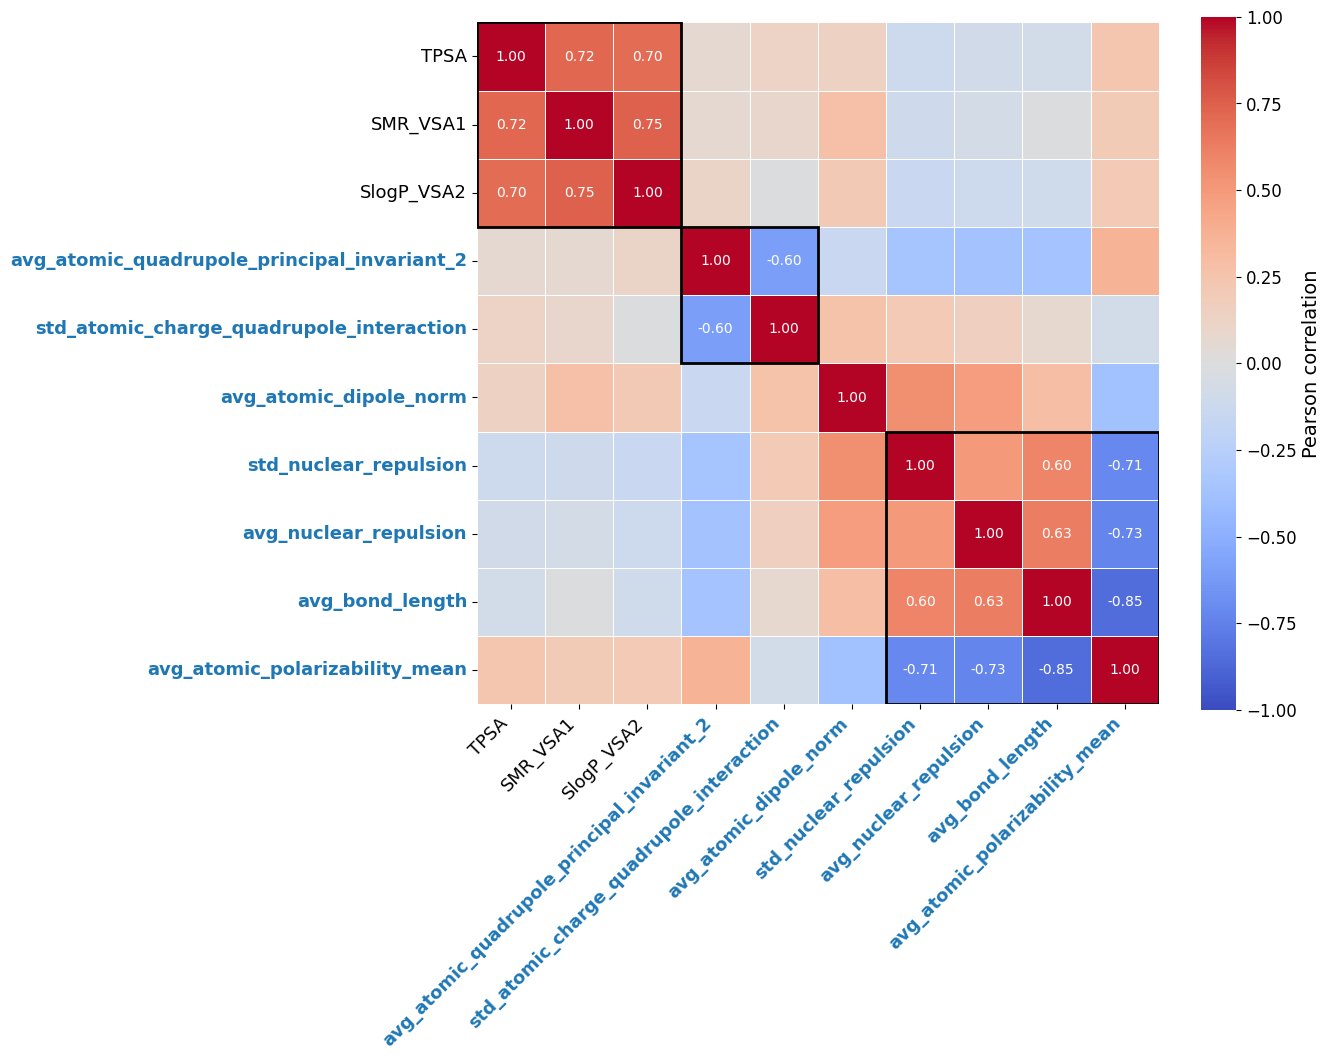

In [26]:
corr = X[top10_feats].corr()

distance_matrix = 1 - np.abs(corr)

linkage_matrix = linkage(
    squareform(distance_matrix),
    method="average"
)


cg = sns.clustermap(
    corr,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    figsize=(12, 12),
    cbar=False
)

plt.close()

reordered_corr = corr.iloc[
    cg.dendrogram_row.reordered_ind,
    cg.dendrogram_col.reordered_ind
]

plt.figure(figsize=(11, 9))

mask = np.triu(np.ones_like(reordered_corr, dtype=bool))

annot = reordered_corr.copy()

# annot = reordered_corr.map(lambda x: f"{x:.2f}" if (x <= -0.49 or x >= 0.49) else "")
annot = reordered_corr.map(lambda x: f"{x:.2f}" if abs(x) >= 0.59 else "")


ax = sns.heatmap(
    reordered_corr,
    # mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    annot=annot,
    fmt="s",
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"}
)

# --- choose number of clusters ---
cluster_labels = fcluster(linkage_matrix, t=4, criterion="maxclust")

# reorder labels according to heatmap ordering
reordered_labels = cluster_labels[cg.dendrogram_row.reordered_ind]

# --- find contiguous cluster blocks ---
blocks = []
start = 0

for i in range(1, len(reordered_labels)):
    if reordered_labels[i] != reordered_labels[i - 1]:
        blocks.append((start, i - start))
        start = i

blocks.append((start, len(reordered_labels) - start))

# --- draw rectangles ---
for start, size in blocks:
    if size <= 1:
        continue
    
    ax.add_patch(
        Rectangle(
            (start, start),   # x,y
            size,             # width
            size,             # height
            fill=False,
            edgecolor="black",
            lw=2
        )
    )

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Pearson correlation", fontsize=14)

for tick in ax.get_xticklabels():
    if tick.get_text() in qm_feats:
        tick.set_color("tab:blue")
        tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    if tick.get_text() in qm_feats:
        tick.set_color("tab:blue")
        tick.set_fontweight("bold")

plt.xticks(rotation=45, ha="right", fontsize=13)
plt.yticks(fontsize=13)

# plt.tight_layout()
# plt.savefig("top10corr2.pdf", format="pdf", bbox_inches="tight")
plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 2

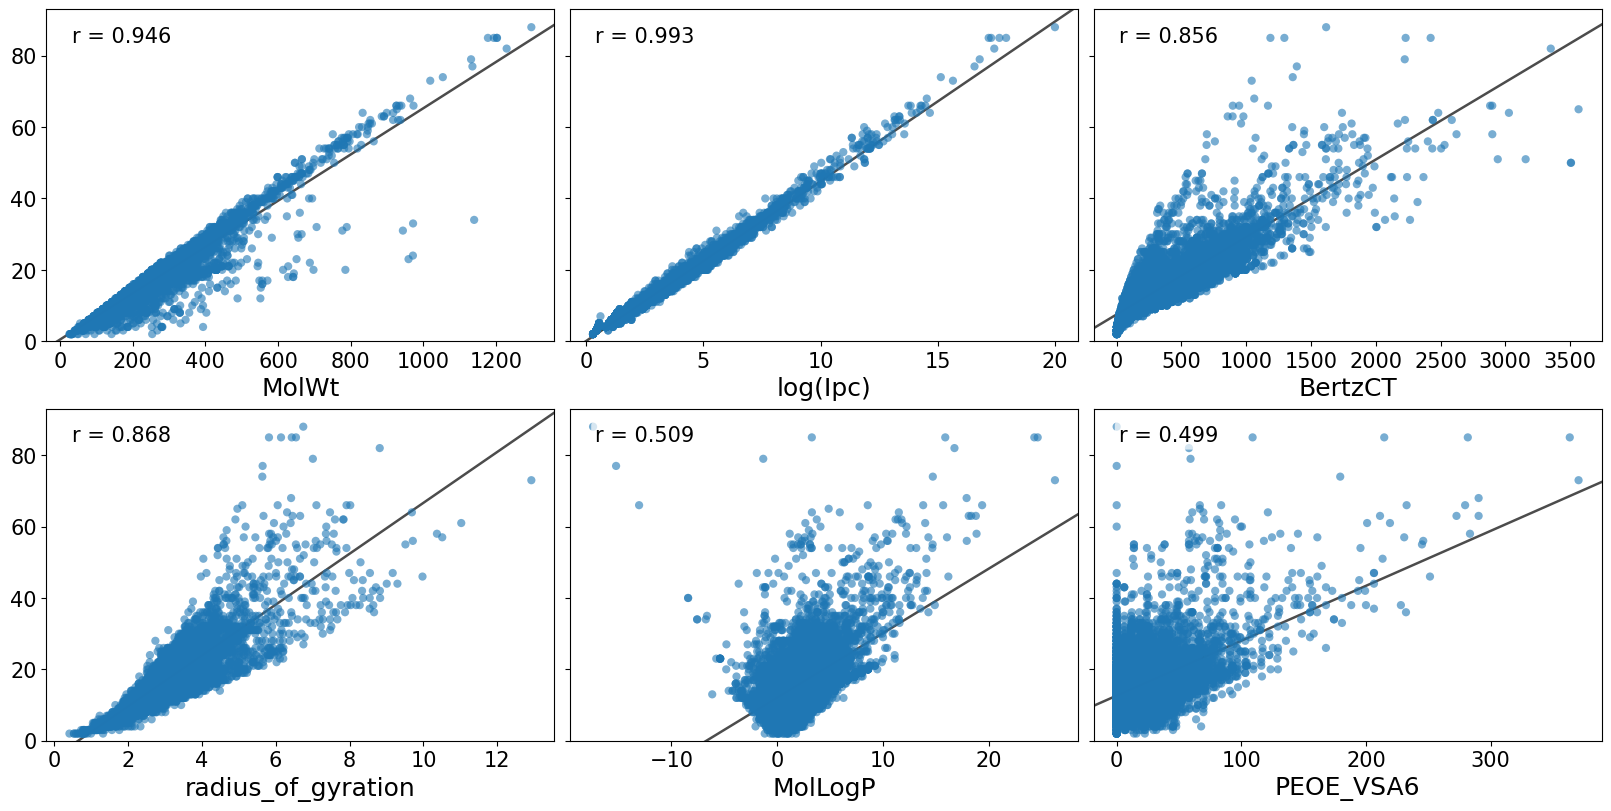

In [18]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 8),
    sharey=True,
    constrained_layout=True
)

plots = [
    ("MolWt", X["HeavyAtomCount"].corr(X["MolWt"])),
    ("log(Ipc)", X["HeavyAtomCount"].corr(X["log(Ipc)"])),
    ("BertzCT", X["HeavyAtomCount"].corr(X["BertzCT"])),
    ("radius_of_gyration", X["HeavyAtomCount"].corr(X["radius_of_gyration"])),
    ("MolLogP", X["HeavyAtomCount"].corr(X["MolLogP"])),
    ("PEOE_VSA6", X["HeavyAtomCount"].corr(X["PEOE_VSA6"])),
    ("molecular_polarizability_mean", X["HeavyAtomCount"].corr(X["molecular_polarizability_mean"])),
    ("ir_mode_count_1500_2750", X["HeavyAtomCount"].corr(X["ir_mode_count_1500_2750"])),
]

scatter_kws = dict(
    s=35,               
    alpha=0.6,          
    edgecolors="none", 
    linewidths=0.0,
    rasterized=True    
)

y = X["HeavyAtomCount"].values

for idx, (feature, corr) in enumerate(plots):

    ax = axes[idx // 3, idx % 3]
    x = X[feature].values

    ax.scatter(
        x, y,
        **scatter_kws,
        zorder=2
    )

    m, b = np.polyfit(x, y, 1)
    x_min, x_max = np.min(x), np.max(x)
    padding = 0.05 * (x_max - x_min)

    x_line = np.linspace(x_min - padding, x_max + padding, 200)
    y_line = m * x_line + b

    ax.plot(
        x_line,
        y_line,
        color="black",
        alpha=0.7,
        linewidth=1.8,
        zorder=1
    )

    ax.set_xlim(x_line.min(), x_line.max())
    ax.set_ylim(0, np.max(y) + 5)

    ax.set_xlabel(feature, fontsize=18)
    ax.tick_params(axis='both', labelsize=15)

    ax.text(
        0.05, 0.95,
        f"r = {corr:.3f}",
        transform=ax.transAxes,
        fontsize=15,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none")
    )

axes[0, 0].set_ylabel("HeavyAtomCount", fontsize=18)
axes[1, 0].set_ylabel("HeavyAtomCount", fontsize=18)

# plt.savefig(
#     "sizecorr.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=300
# )

plt.show()